# **Brain Stroke Prediction**

**Data Dictionary**

Training Data(df): Brain Stroke Data

Training Unseen Data(df_unseen): Brain Stroke Unseen Data

**Import Libraries**

In [277]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

**Load Datasets**

In [278]:
# Load the training dataset
df = pd.read_csv("./processed_datasets/brain_stroke/brain_stroke_data.csv")

df.head(5)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,46.0,0,0,Yes,Private,Urban,78.79,42.4,smokes,0
1,Female,65.0,0,0,Yes,Self-employed,Urban,248.24,27.0,smokes,0
2,Male,70.0,1,0,Yes,Self-employed,Rural,118.81,26.0,smokes,0
3,Male,47.0,0,0,Yes,Private,Urban,111.84,33.7,Unknown,0
4,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0


In [279]:
# Load the unseen dataset
df_unseen = pd.read_csv("./processed_datasets/brain_stroke/brain_stroke_unseen.csv")

df_unseen.head(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Female,49.0,0,0,Yes,Private,Rural,56.11,28.7,smokes
1,Male,75.0,0,0,Yes,Private,Rural,75.47,24.5,formerly smoked
2,Female,71.0,0,0,Yes,Private,Rural,100.61,19.2,Unknown
3,Female,12.0,0,0,No,children,Rural,85.97,35.7,Unknown
4,Male,63.0,0,0,Yes,Private,Rural,104.79,24.1,Unknown


In [280]:
# Standardise column names to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(" ", "_")
df_unseen.columns = df_unseen.columns.str.lower().str.replace(" ", "_")

df.columns, df_unseen.columns   

(Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
        'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
        'smoking_status', 'stroke'],
       dtype='object'),
 Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
        'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
        'smoking_status'],
       dtype='object'))

**EDA**

In [281]:
# Display basic information about the DataFrame
def data_info(df):
    print("DataFrame Info:") # info
    print(df.info())
    print("\nDataFrame Shape:") # shape
    print(df.shape)
    print("DataFrame Columns:") # columns
    print(df.columns.tolist())  
    print("DataFrame Missing Values:") # missing values
    print(df.isna().sum())

data_info(df)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4482 entries, 0 to 4481
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4482 non-null   object 
 1   age                4482 non-null   float64
 2   hypertension       4482 non-null   int64  
 3   heart_disease      4482 non-null   int64  
 4   ever_married       4482 non-null   object 
 5   work_type          4482 non-null   object 
 6   residence_type     4482 non-null   object 
 7   avg_glucose_level  4482 non-null   float64
 8   bmi                4482 non-null   float64
 9   smoking_status     4482 non-null   object 
 10  stroke             4482 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 385.3+ KB
None

DataFrame Shape:
(4482, 11)
DataFrame Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'avg_glucose_level', 'bmi', 'smoking_s

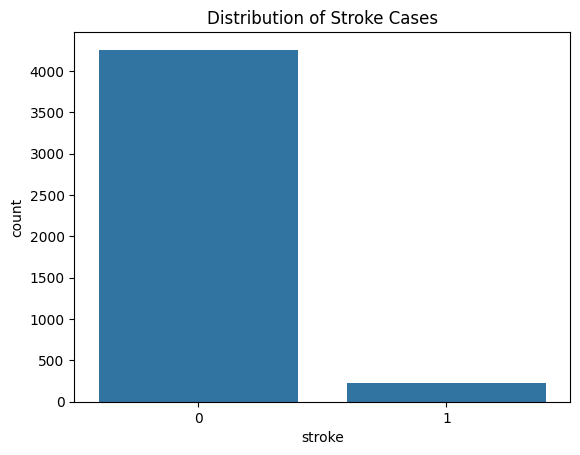

stroke
0    95.02
1     4.98
Name: proportion, dtype: float64

In [282]:
# Check for class imbalance
sns.countplot (x = "stroke", data = df)
plt.title("Distribution of Stroke Cases")
plt.show()

# percentage
round(df["stroke"].value_counts(normalize=True) * 100, 2)

In [284]:
# Seperate numerical and categorical features for exploratory data analysis
num_cols = df.select_dtypes(include=["float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "int64"]).columns.tolist()
cat_cols.remove("stroke") # Exclude target variable from categorical columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['age', 'avg_glucose_level', 'bmi']
Categorical Columns: ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'smoking_status']


Numerical Data EDA

In [285]:
# Distribution of numerical features 
def numerical_stats(num_cols):
    print("Numerical Features Statistics:")
    print(num_cols.describe().round(2))

numerical_stats(df[num_cols])

Numerical Features Statistics:
           age  avg_glucose_level      bmi
count  4482.00            4482.00  4482.00
mean     43.45             105.76    28.47
std      22.59              44.94     6.76
min       0.08              55.12    14.00
25%      26.00              77.19    23.60
50%      45.00              91.68    28.10
75%      61.00             113.64    32.58
max      82.00             267.76    48.90


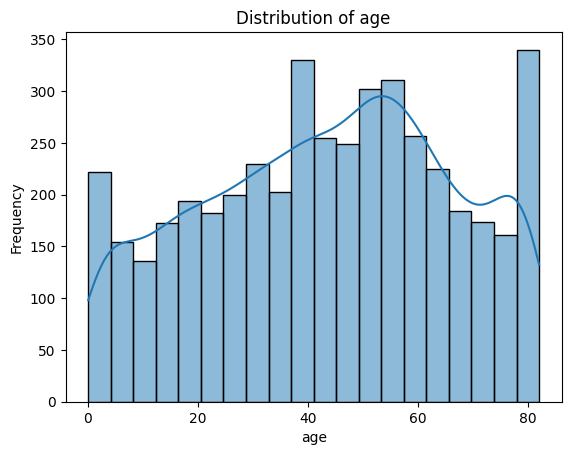

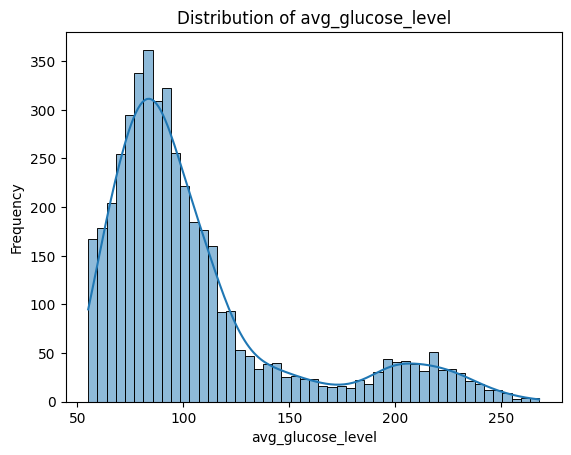

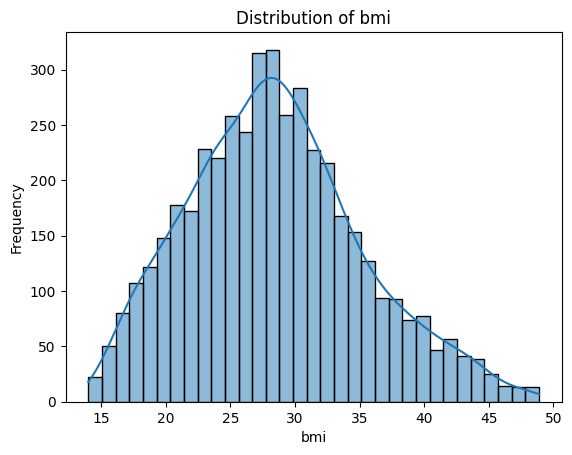

In [286]:
# Visualise distribution
def plot_numeric_distributions(df):

    for col in num_cols:
        sns.histplot(data=df, x=col, kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

plot_numeric_distributions(df)

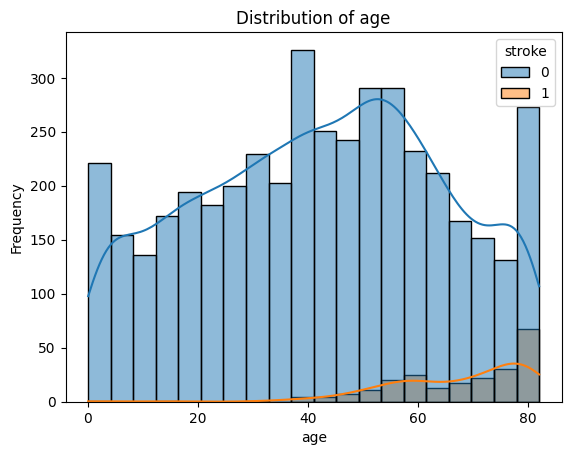

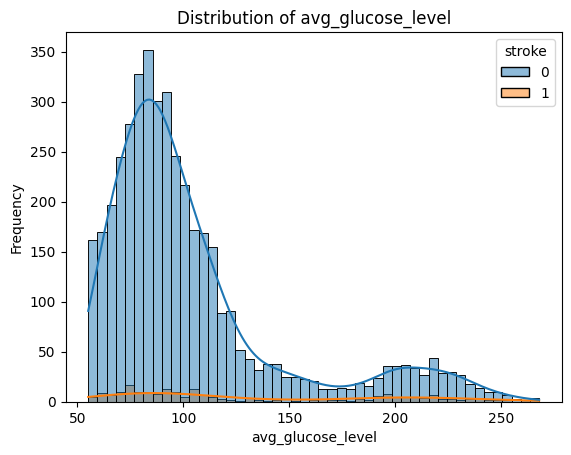

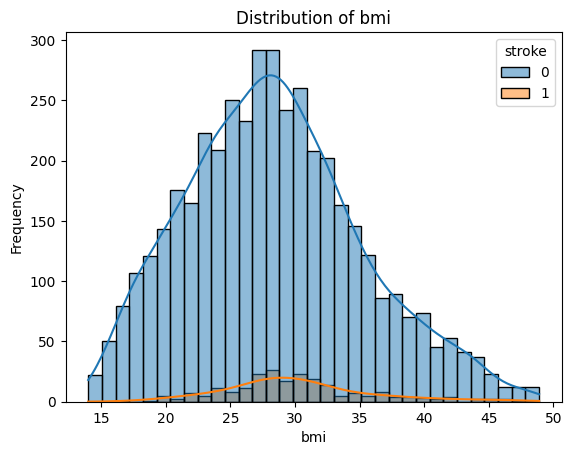

In [287]:
# Distribution with respect to target variable
def plot_numeric_distributions(df):

    for col in num_cols:
        sns.histplot(data=df, x=col, hue = "stroke", kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

plot_numeric_distributions(df)

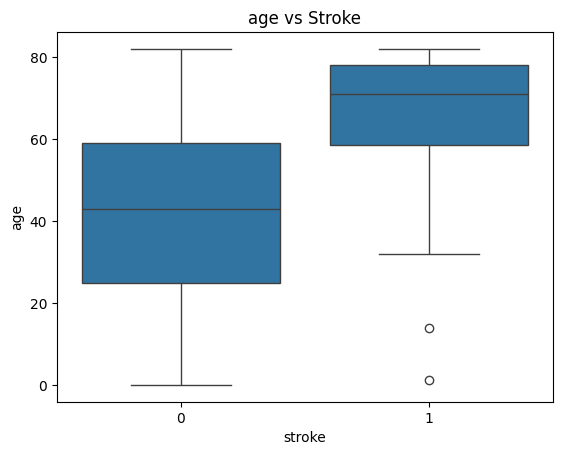

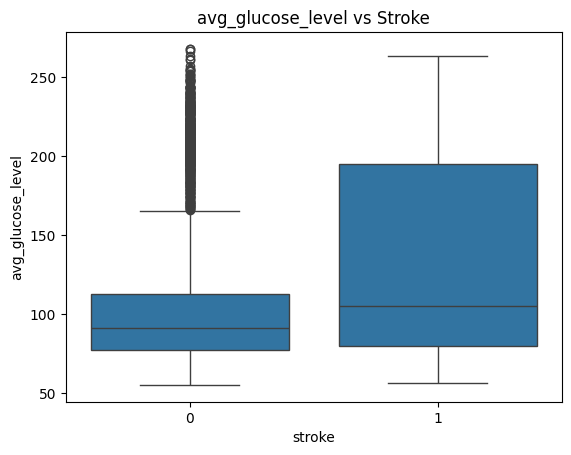

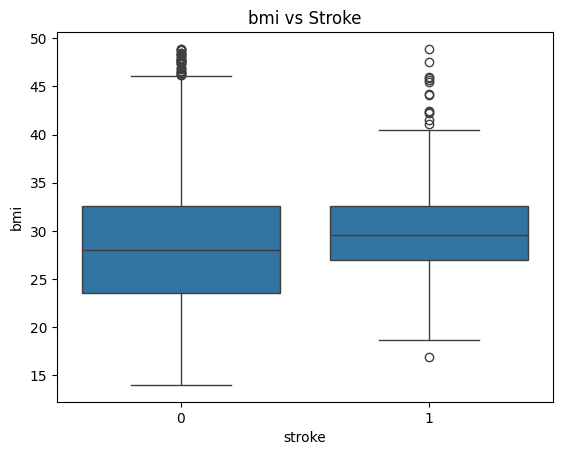

In [288]:
# Visualise using boxplots to check relationship between numerical features and target variable
for col in num_cols:
    sns.boxplot(x="stroke", y=col, data=df)
    plt.title(f"{col} vs Stroke")
    plt.show()

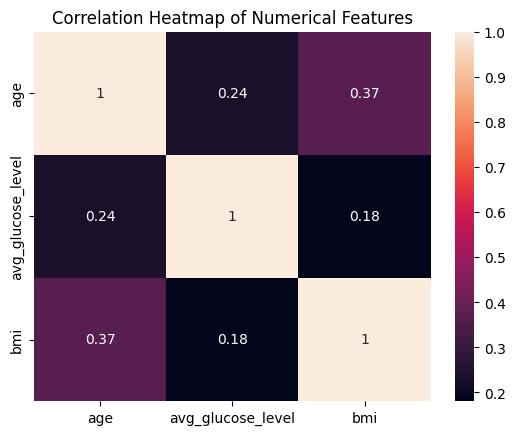

In [289]:
# Coorelation between numerical features
sns.heatmap(df[num_cols].corr(), annot=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

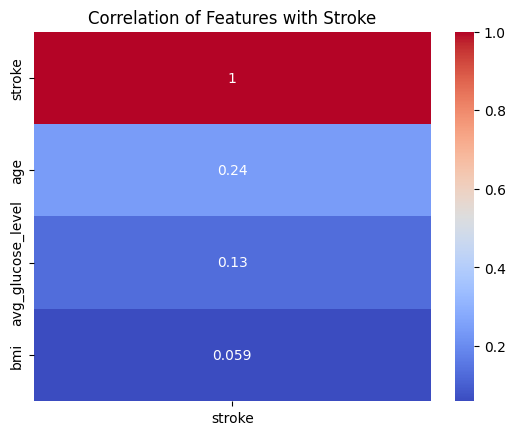

In [291]:
# Correlation of features with target variable
corr = df[num_cols + ["stroke"]].corr()

sns.heatmap(
    corr[["stroke"]].sort_values(by="stroke", ascending=False),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation of Features with Stroke")
plt.show()

Categorical Data EDA

In [292]:
# Function to display value counts and percentages for categorical features
def categorical_value_counts(df):
    for col in cat_cols:
        print(f"Value counts for '{col}':")
        
        counts = df[col].value_counts()
        perc = df[col].value_counts(normalize=True) * 100
        
        summary = pd.DataFrame({
            "Count": counts,
            "Percentage (%)": round(perc, 2)
        })
        
        print(summary)
        print("\n")
        
categorical_value_counts(df)

Value counts for 'gender':
        Count  Percentage (%)
gender                       
Female   2600           58.01
Male     1882           41.99


Value counts for 'hypertension':
              Count  Percentage (%)
hypertension                       
0              4041           90.16
1               441            9.84


Value counts for 'heart_disease':
               Count  Percentage (%)
heart_disease                       
0               4237           94.53
1                245            5.47


Value counts for 'ever_married':
              Count  Percentage (%)
ever_married                       
Yes            2951           65.84
No             1531           34.16


Value counts for 'work_type':
               Count  Percentage (%)
work_type                           
Private         2571           57.36
Self-employed    721           16.09
children         602           13.43
Govt_job         588           13.12


Value counts for 'residence_type':
                Coun

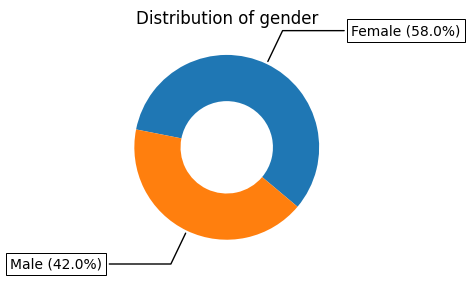

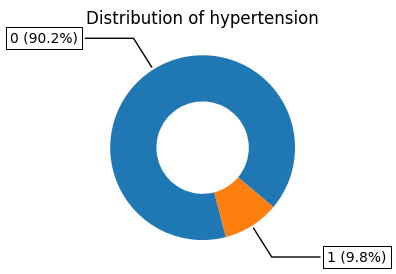

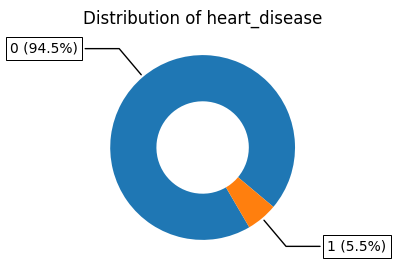

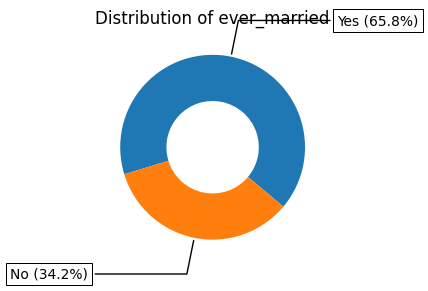

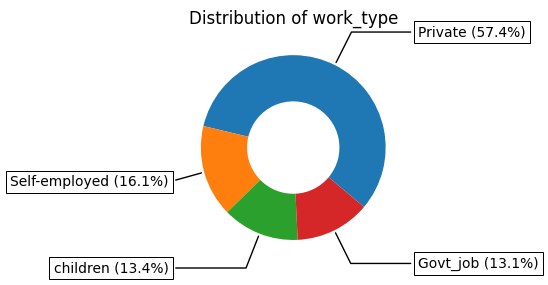

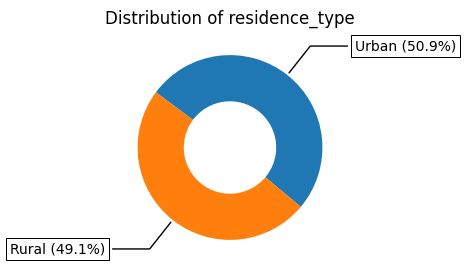

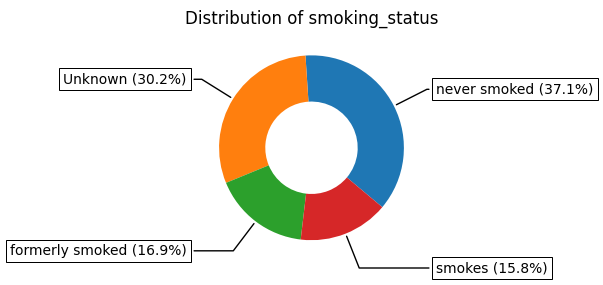

In [293]:
# Visualise categorical features
# Pie chart code reference from: https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html

def visualise_categorical_features(df):
    
    for column in cat_cols:
        
        counts = df[column].value_counts()
        
        labels = counts.index.astype(str)
        data = counts.values
        total = data.sum()
        
        fig, ax = plt.subplots(figsize=(6, 3), subplot_kw=dict(aspect="equal"))
        
        wedges, texts = ax.pie(
            data,
            wedgeprops=dict(width=0.5),
            startangle=-40
        )
        
        # annotation style
        bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
        kw = dict(
            arrowprops=dict(arrowstyle="-"),
            bbox=bbox_props,
            zorder=0,
            va="center"
        )
        
        for i, p in enumerate(wedges):
            ang = (p.theta2 - p.theta1)/2. + p.theta1
            y = np.sin(np.deg2rad(ang))
            x = np.cos(np.deg2rad(ang))
            
            horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
            connectionstyle = f"angle,angleA=0,angleB={ang}"
            
            kw["arrowprops"].update({"connectionstyle": connectionstyle})
            
            percentage = data[i] / total * 100
            
            ax.annotate(
                f"{labels[i]} ({percentage:.1f}%)",
                xy=(x, y),
                xytext=(1.35*np.sign(x), 1.4*y),
                horizontalalignment=horizontalalignment,
                **kw
            )
        
        ax.set_title(f"Distribution of {column}")
        plt.show()

visualise_categorical_features(df)

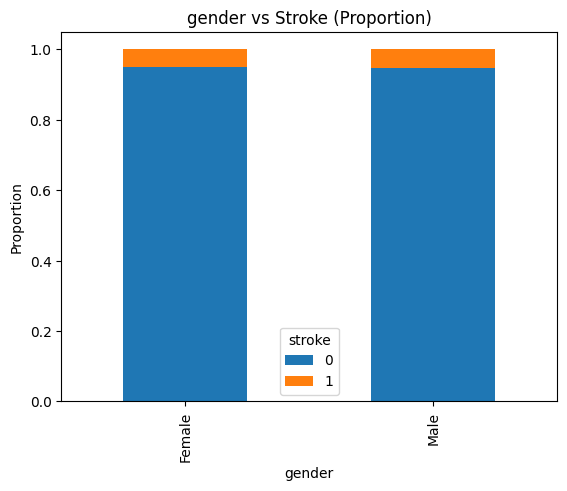

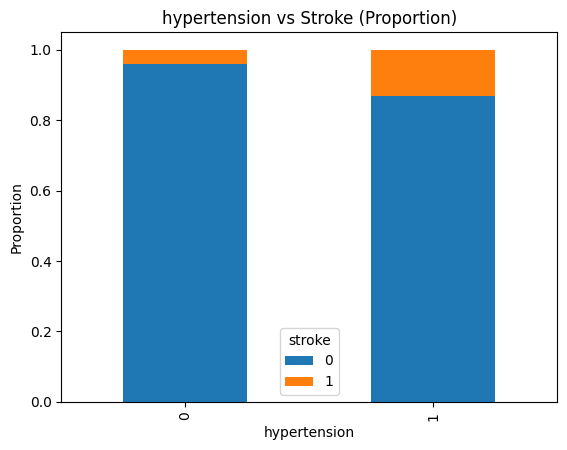

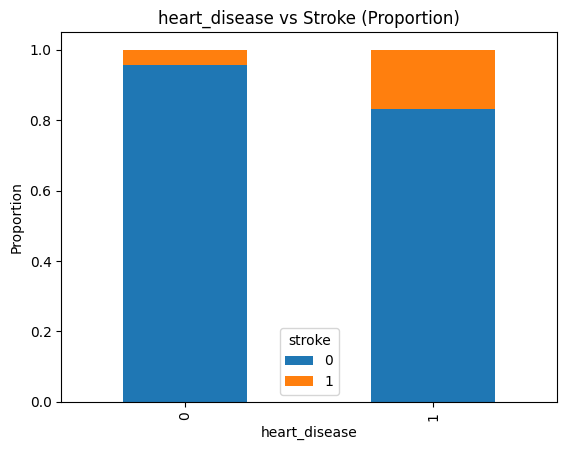

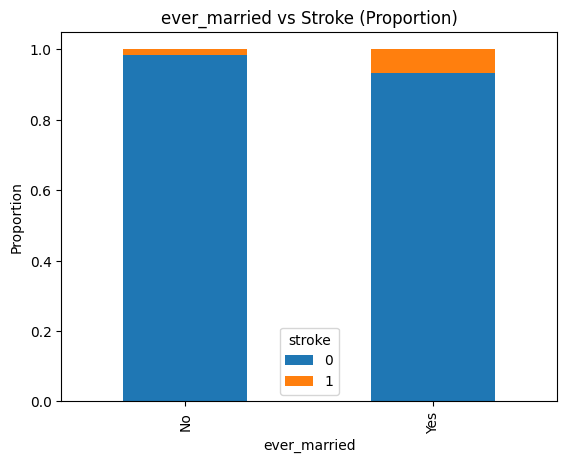

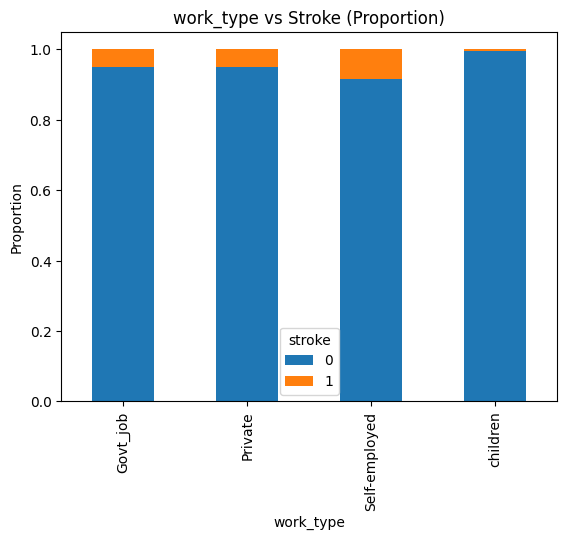

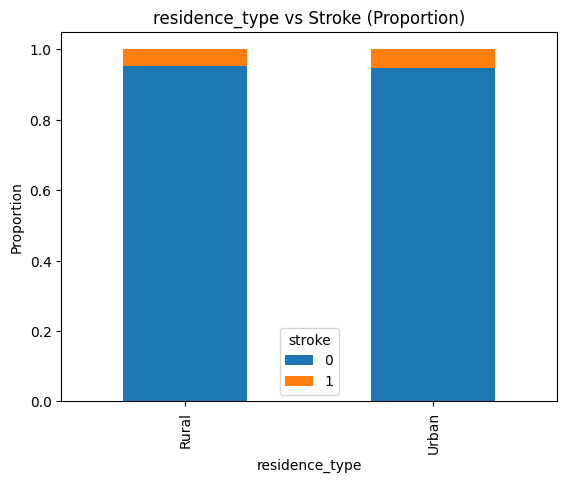

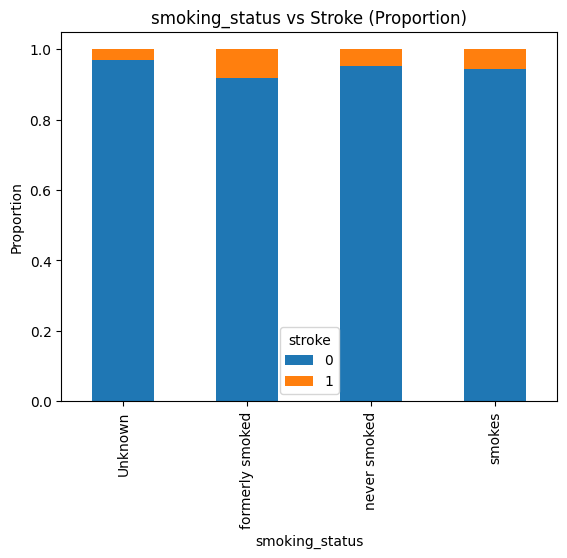

In [294]:
# Stacked bar chart to show relationship between categorical features and target variable

for col in cat_cols:
    ct = pd.crosstab(df[col], df["stroke"], normalize="index")
    ct.plot(kind="bar", stacked=True)
    plt.title(f"{col} vs Stroke (Proportion)")
    plt.ylabel("Proportion")
    plt.show()

**Pre Process**

Data Encode

In [295]:
encoder = OneHotEncoder(sparse_output = False)

onehot_encoded = encoder.fit_transform(df[cat_cols])
one_hot_df = pd.DataFrame(onehot_encoded, columns=encoder.get_feature_names_out(cat_cols))
df_encoded = pd.concat([df[num_cols], one_hot_df, df["stroke"]], axis=1)

df_encoded.head()


,age,avg_glucose_level,bmi,gender_Female,gender_Male,hypertension_0,hypertension_1,heart_disease_0,heart_disease_1,ever_married_No,...,work_type_Private,work_type_Self-employed,work_type_children,residence_type_Rural,residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,46.0,78.79,42.4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
1,65.0,248.24,27.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
2,70.0,118.81,26.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
3,47.0,111.84,33.7,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0
4,31.0,65.70,30.4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0


Standardisation

Start with splitting data into train and test before standard scaling to prevent data leakage.

In [296]:
X = df_encoded.drop("stroke", axis=1)
y = df_encoded["stroke"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((3585, 21), (897, 21), (3585,), (897,))

In [297]:
# Scale the numerical features using StandardScaler
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,age,avg_glucose_level,bmi,gender_Female,gender_Male,hypertension_0,hypertension_1,heart_disease_0,heart_disease_1,ever_married_No,...,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,residence_type_Rural,residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
2211,0.920145,2.367160,0.331167,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4249,-0.890916,-0.152243,-0.025690,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
100,-0.272505,2.495936,0.093262,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
12,1.626900,-0.323050,0.658286,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2459,-1.067605,-0.646108,-0.278464,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


Oversampling

In [298]:
sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before resampling:")
print(y_train.value_counts())
print("After resampling:")
print(y_train_res.value_counts())

Before resampling:
stroke
0    3405
1     180
Name: count, dtype: int64
After resampling:
stroke
0    3405
1    3405
Name: count, dtype: int64


**Model**

In [299]:
def train_and_evaluate(model, X_train_res, y_train_res, X_test, y_test):
    """
    Train model and return predictions + evaluation metrics
    """
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    
    print(f"\n{model.__class__.__name__}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return y_pred

In [300]:
models = [
    LogisticRegression(max_iter=1000),
    KNeighborsClassifier(n_neighbors=5),
    SVC(kernel="rbf"),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42)
]

In [301]:
results = {}

for model in models:
    y_pred = train_and_evaluate(model, X_train_res, y_train_res, X_test, y_test)
    results[model.__class__.__name__] = y_pred


LogisticRegression
Confusion Matrix:
[[609 245]
 [ 11  32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.71      0.83       854
           1       0.12      0.74      0.20        43

    accuracy                           0.71       897
   macro avg       0.55      0.73      0.51       897
weighted avg       0.94      0.71      0.80       897


KNeighborsClassifier
Confusion Matrix:
[[719 135]
 [ 26  17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       854
           1       0.11      0.40      0.17        43

    accuracy                           0.82       897
   macro avg       0.54      0.62      0.54       897
weighted avg       0.92      0.82      0.86       897


SVC
Confusion Matrix:
[[706 148]
 [ 19  24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.89      